In [36]:
import torch

def axis_angle_to_matrix_batched(axis, angle):
    """
    Rodrigues' rotation formula (Batched)
    axis: (B, 3)
    angle: (B, 1)
    return: (B, 3, 3)
    """
    B = axis.shape[0]
    device = axis.device
    dtype = axis.dtype
    
    x, y, z = axis[:, 0], axis[:, 1], axis[:, 2]
    zeros = torch.zeros_like(x)
    
    # Skew-symmetric matrix K
    K = torch.stack([
        torch.stack([zeros, -z, y], dim=-1),
        torch.stack([z, zeros, -x], dim=-1),
        torch.stack([-y, x, zeros], dim=-1)
    ], dim=1) # (B, 3, 3)
    
    I = torch.eye(3, device=device, dtype=dtype).unsqueeze(0).expand(B, 3, 3)
    
    sin_a = torch.sin(angle).view(B, 1, 1)
    cos_a = torch.cos(angle).view(B, 1, 1)
    
    # R = I + sin(theta)K + (1-cos(theta))K^2
    R = I + sin_a * K + (1 - cos_a) * torch.matmul(K, K)
    return R

def apply_global_rigid_transform(batch, diffuse_mask, translation_scale=4.0, rotation_scale=0.5):
    """
    batch: {'bb_positions': tensor(B, L, 3)}
    diffuse_mask: shape (B, L) or (L,)
    """
    target_key = 'bb_positions'
    
    if target_key not in batch:
        return {k: v.clone() for k, v in batch.items()}

    coords = batch[target_key] # (B, L, 3)
    B, L, _ = coords.shape
    device = coords.device
    dtype = coords.dtype

    # ---------------------------
    # 1) Mask Preparation (Broadcasting)
    # ---------------------------
    # 입력 mask가 (L,)이면 (1, L, 1) -> (B, L, 1)
    # 입력 mask가 (B, L)이면 (B, L, 1)
    if diffuse_mask.dim() == 1:
        mask_bool = diffuse_mask.view(1, L, 1).expand(B, L, 1).bool()
    else:
        mask_bool = diffuse_mask.view(B, L, 1).bool()

    mask_float = mask_bool.float()

    # ---------------------------
    # 2) Center of Mass (Batch-wise)
    # ---------------------------
    # (B, L, 3) * (B, L, 1) -> sum -> (B, 3)
    masked_sum = (coords * mask_float).sum(dim=1)
    mask_count = mask_float.sum(dim=1) # (B, 1)
    mask_count = torch.clamp(mask_count, min=1.0) # 0 나누기 방지
    
    center = masked_sum / mask_count
    center = center.view(B, 1, 3) # (B, 1, 3)

    # ---------------------------
    # 3) Batch Random Rotation & Translation
    # ---------------------------
    if rotation_scale > 1e-6:
        # Axis: (B, 3)
        rand_axis = torch.randn(B, 3, device=device, dtype=dtype)
        rand_axis = rand_axis / (torch.norm(rand_axis, dim=1, keepdim=True) + 1e-6)
        
        # Angle: (B, 1)
        rand_angle = (torch.rand(B, 1, device=device, dtype=dtype) * 2 - 1) * rotation_scale
        
        R = axis_angle_to_matrix_batched(rand_axis, rand_angle) # (B, 3, 3)
    else:
        R = torch.eye(3, device=device, dtype=dtype).unsqueeze(0).expand(B, 3, 3)

    t = torch.randn(B, 3, device=device, dtype=dtype) * translation_scale
    t = t.view(B, 1, 3)

    # ---------------------------
    # 4) Apply Transform
    # ---------------------------
    # R^T (Transpose for multiplying on the right)
    R_T = R.transpose(1, 2) # (B, 3, 3)
    
    # Effective Translation: t_eff = C - C@R^T + t
    # center: (B, 1, 3)
    center_rotated = torch.matmul(center, R_T)
    t_effective = center - center_rotated + t # (B, 1, 3)
    
    # 전체 좌표 변환: (B, L, 3) @ (B, 3, 3) + (B, 1, 3)
    rotated_all = torch.matmul(coords, R_T)
    transformed_all = rotated_all + t_effective

    # ---------------------------
    # 5) Combine using torch.where [핵심 수정 부분]
    # ---------------------------
    # mask_bool: (B, L, 1) -> 자동으로 (B, L, 3)으로 브로드캐스팅되어 조건 적용
    new_coords = torch.where(mask_bool, transformed_all, coords)

    return {target_key: new_coords}

In [38]:
from data.utils import read_pkl

data = read_pkl("/home/psh/benchmark_after210930/meta/7quh_H_L_A.pkl")

for key in data.keys():
    data[key] = torch.tensor(data[key])

data['bb_positions'] = data['bb_positions'][None, ...].repeat(10, 1, 1)
mask = ((data["chain_index"] == 33) | (data["chain_index"] == 37)).float()[None, ...].repeat(10, 1)



new_data = apply_global_rigid_transform(data, mask)
atom_positions_s = new_data['bb_positions']


In [39]:
import os
import torch
import numpy as np

def tensor_to_pdb_block_ca(tensor, model_num=1, chain_id='A'):
    """
    (L, 3) 크기의 CA 좌표 텐서를 PDB 포맷의 텍스트 블록으로 변환
    """
    coords = tensor.detach().cpu().numpy() # Shape: (L, 3)
    L = coords.shape[0]
    
    pdb_lines = []
    pdb_lines.append(f"MODEL     {model_num}")
    
    atom_serial = 1
    for i in range(L):
        # 좌표 가져오기 (L, 3 이므로 인덱싱은 i만 필요)
        pos = coords[i]
        
        # (0,0,0) 패딩 건너뛰기
        if np.sum(np.abs(pos)) < 1e-6:
            continue
        
        res_seq = i + 1
        res_name = 'ALA'  # Backbone만 있으므로 ALA로 통일
        atom_name = ' CA ' # PDB 포맷에서 CA는 보통 앞뒤 공백 포함 4글자
        
        # PDB ATOM Record Format
        # Columns 13-16: Atom name ( " CA " )
        line = (f"ATOM  {atom_serial:>5d} {atom_name:^4s} {res_name:>3s} "
                f"{chain_id:>1s}{res_seq:>4d}    "
                f"{pos[0]:>8.3f}{pos[1]:>8.3f}{pos[2]:>8.3f}"
                f"  1.00  0.00           C")
        
        pdb_lines.append(line)
        atom_serial += 1
            
    pdb_lines.append("ENDMDL")
    return "\n".join(pdb_lines)

def save_individual_pdbs(tensor_list, output_dir="/home/psh/protein-frame-flow/notebook/output_pdbs"):
    os.makedirs(output_dir, exist_ok=True)
    
    for i, tensor in enumerate(tensor_list):
        # [수정됨] CA 전용 함수 호출
        pdb_content = tensor_to_pdb_block_ca(tensor, model_num=1)
        
        # 파일명: 0.pdb, 1.pdb ...
        save_path = os.path.join(output_dir, f"{i}.pdb")
        
        with open(save_path, 'w') as f:
            f.write(pdb_content)
            
    print(f"Saved {len(tensor_list)} CA-trace PDB files in '{output_dir}'")

# 실행
# atom_positions_s는 [L, 3] 텐서들의 리스트여야 합니다.
save_individual_pdbs(atom_positions_s)

Saved 10 CA-trace PDB files in '/home/psh/protein-frame-flow/notebook/output_pdbs'


## distance map과 contact map 분리해서 시각화 

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from Bio.PDB import PDBParser

CHOTHIA_CDR = {
    "H": {
        "CDR1": range(26, 33),
        "CDR2": range(52, 57),
        "CDR3": range(95, 103),
    },
    "L": {
        "CDR1": range(24, 35),
        "CDR2": range(50, 57),
        "CDR3": range(89, 98),
    }
}


def is_cdr(resnum, chain_type):
    for r in CHOTHIA_CDR[chain_type].values():
        if resnum in r:
            return True
    return False

def extract_chain(chain, chain_type=None, atom="CA"):
    coords, cdr_mask = [], []

    for res in chain:
        if atom not in res:
            continue
        coords.append(res[atom].coord)

        if chain_type is None:
            cdr_mask.append(False)
        else:
            cdr_mask.append(is_cdr(res.id[1], chain_type))

    return np.array(coords), np.array(cdr_mask)

def plot_distance_map(pdb_path, ab_chain_types=("H", "L"), vmax=30):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("complex", pdb_path)
    model = next(structure.get_models())
    chains = list(model.get_chains())

    # antibody
    ab_coords, ab_cdr = [], []
    for chain, ctype in zip(chains[:2], ab_chain_types):
        c, cdr = extract_chain(chain, ctype)
        ab_coords.append(c)
        ab_cdr.append(cdr)

    ab_coords = np.concatenate(ab_coords, axis=0)
    ab_cdr = np.concatenate(ab_cdr, axis=0)

    # antigen
    ag_coords, _ = extract_chain(chains[2], None)

    # Ab–Ab distance
    diff_ab = ab_coords[:, None, :] - ab_coords[None, :, :]
    dist_ab = np.linalg.norm(diff_ab, axis=-1)

    for i in range(len(ab_coords)):
        if ab_cdr[i]:
            dist_ab[i, :] = 0
            dist_ab[:, i] = 0

    # Ag–Ag distance
    diff_ag = ag_coords[:, None, :] - ag_coords[None, :, :]
    dist_ag = np.linalg.norm(diff_ag, axis=-1)

    # block-diagonal distance map
    N_ab = len(ab_coords)
    N_ag = len(ag_coords)
    dist_map = np.zeros((N_ab + N_ag, N_ab + N_ag))
    dist_map[:N_ab, :N_ab] = dist_ab
    dist_map[N_ab:, N_ab:] = dist_ag

    # plot
    plt.figure(figsize=(6, 6))
    im = plt.imshow(dist_map, cmap="viridis", vmin=0, vmax=vmax)
    plt.axvline(N_ab - 0.5, color="white")
    plt.axhline(N_ab - 0.5, color="white")
    plt.tight_layout()
    plt.show()

def plot_contact_map(
    pdb_path,
    ab_chain_types=("H", "L"),
    threshold=20.0,
    vmax=30  # distance map과 동일한 스케일
):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("complex", pdb_path)
    model = next(structure.get_models())
    chains = list(model.get_chains())

    # ------------------
    # Antibody
    # ------------------
    ab_coords, ab_cdr = [], []
    for chain, ctype in zip(chains[:2], ab_chain_types):
        c, cdr = extract_chain(chain, ctype)
        ab_coords.append(c)
        ab_cdr.append(cdr)

    ab_coords = np.concatenate(ab_coords, axis=0)
    ab_cdr = np.concatenate(ab_cdr, axis=0)

    # ------------------
    # Antigen
    # ------------------
    ag_coords, _ = extract_chain(chains[2], None)

    N_ab = len(ab_coords)
    N_ag = len(ag_coords)
    L = N_ab + N_ag

    # ------------------
    # Ab–Ag contact
    # ------------------
    diff = ab_coords[:, None, :] - ag_coords[None, :, :]
    dist = np.linalg.norm(diff, axis=-1)

    contact = (dist < threshold).astype(float)

    # CDR masking (Ab side)
    for i in range(N_ab):
        if ab_cdr[i]:
            contact[i, :] = 0

    # ------------------
    # L x L contact map
    # ------------------
    contact_map = np.zeros((L, L))
    contact_map[:N_ab, N_ab:] = contact * 30
    contact_map[N_ab:, :N_ab] = contact.T * 30

    # ------------------
    # Plot
    # ------------------
    plt.figure(figsize=(6, 6))
    im = plt.imshow(contact_map, cmap="viridis", vmin=0, vmax=vmax)

    plt.axvline(N_ab - 0.5, color="white")
    plt.axhline(N_ab - 0.5, color="white")

    plt.tight_layout()
    plt.show()



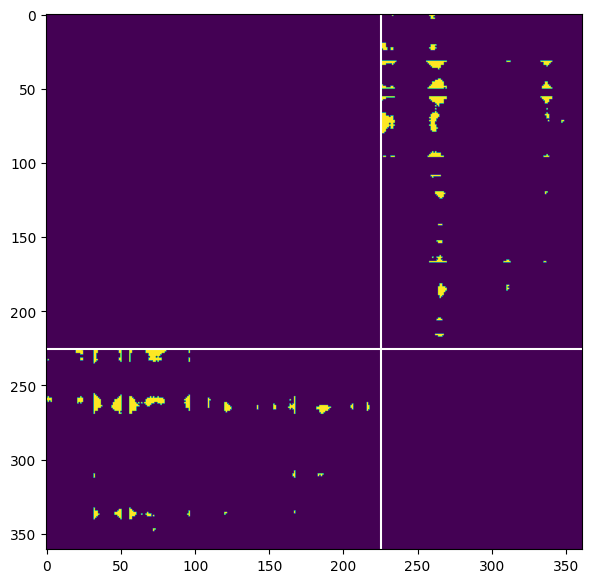

In [24]:
pdb_path = "/home/psh/benchmark_after210930/pdb/7quh_H_L_A.pdb"

# plot_distance_map(pdb_path)
plot_contact_map(pdb_path)


## distance map - contact map fusion 

In [9]:
CHOTHIA_CDR = {
    "H": {
        "CDR1": range(26, 33),
        "CDR2": range(52, 57),
        "CDR3": range(95, 103),
    },
    "L": {
        "CDR1": range(24, 35),
        "CDR2": range(50, 57),
        "CDR3": range(89, 98),
    }
}
import numpy as np
import matplotlib.pyplot as plt
from Bio.PDB import PDBParser


def is_cdr(resnum, chain_type):
    for r in CHOTHIA_CDR[chain_type].values():
        if resnum in r:
            return True
    return False


def extract_chain_coords(chain, chain_type=None, atom_name="CA"):
    coords, is_cdr_list = [], []

    for res in chain:
        if atom_name not in res:
            continue
        coords.append(res[atom_name].coord)
        if chain_type is None:
            is_cdr_list.append(False)
        else:
            is_cdr_list.append(is_cdr(res.id[1], chain_type))

    return np.array(coords), np.array(is_cdr_list)

def build_pair_feature(pdb_path, ab_chain_types=("H", "L"), contact_th=20.0):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("complex", pdb_path)

    model = next(structure.get_models())
    chains = list(model.get_chains())

    # antibody chains (0,1), antigen chain (2)
    ab_coords, ab_cdr = [], []
    for chain, ctype in zip(chains[:2], ab_chain_types):
        c, cdr = extract_chain_coords(chain, ctype)
        ab_coords.append(c)
        ab_cdr.append(cdr)

    ag_coords, ag_cdr = extract_chain_coords(chains[2], None)

    ab_coords = np.concatenate(ab_coords, axis=0)
    ab_cdr = np.concatenate(ab_cdr, axis=0)

    # sizes
    N_ab = len(ab_coords)
    N_ag = len(ag_coords)
    N = N_ab + N_ag

    pair = np.zeros((N, N))

    # ---- Ab–Ab (distance, CDR masked)
    diff_ab = ab_coords[:, None, :] - ab_coords[None, :, :]
    dist_ab = np.linalg.norm(diff_ab, axis=-1)

    for i in range(N_ab):
        if ab_cdr[i]:
            dist_ab[i, :] = 0
            dist_ab[:, i] = 0

    pair[:N_ab, :N_ab] = dist_ab

    # ---- Ag–Ag (distance only)
    diff_ag = ag_coords[:, None, :] - ag_coords[None, :, :]
    dist_ag = np.linalg.norm(diff_ag, axis=-1)
    pair[N_ab:, N_ab:] = dist_ag

    # ---- Ab–Ag contact map (CDR masked)
    diff_ab_ag = ab_coords[:, None, :] - ag_coords[None, :, :]
    dist_ab_ag = np.linalg.norm(diff_ab_ag, axis=-1)

    contact = (dist_ab_ag < contact_th).astype(float) * 30

    for i in range(N_ab):
        if ab_cdr[i]:
            contact[i, :] = 0

    pair[:N_ab, N_ab:] = contact
    pair[N_ab:, :N_ab] = contact.T

    return pair, N_ab

def plot_pair_feature(pair, N_ab, vmax_dist=30):
    plt.figure(figsize=(7, 7))
    im = plt.imshow(pair, cmap="viridis", vmin=0, vmax=vmax_dist)

    plt.axvline(N_ab - 0.5, color="white")
    plt.axhline(N_ab - 0.5, color="white")


    plt.title("Pair feature\nDiag: distance (CDR masked) | Off-diag: contact (CDR masked)")
    plt.tight_layout()
    plt.show()



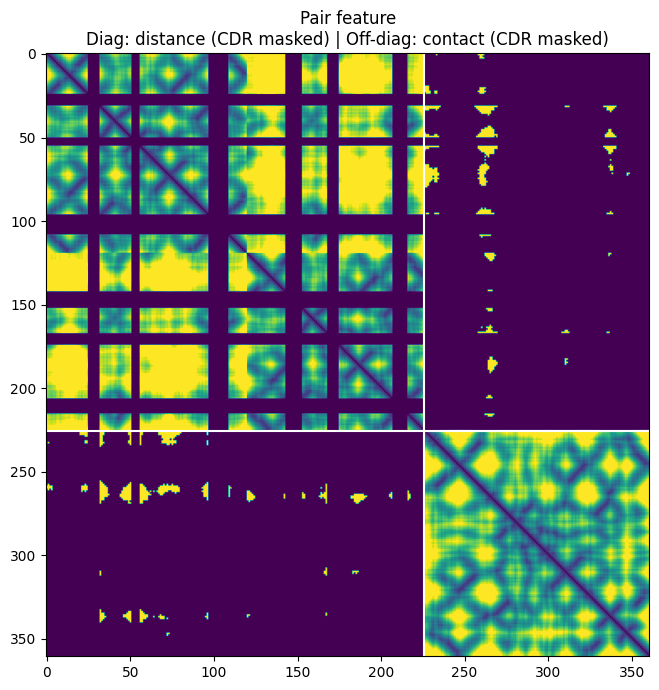

In [10]:
pdb_path = "/home/psh/benchmark_after210930/pdb/7quh_H_L_A.pdb"

pair, N_ab = build_pair_feature(
    pdb_path,
    ab_chain_types=("H", "L"),
    contact_th=20.0
)

plot_pair_feature(pair, N_ab)
